In [ ]:
!pip install sqlalchemy-iris
!pip install drawdata

In [1]:
1

1

In [3]:
import datetime as dt
from drawdata import ScatterWidget
from sqlalchemy import create_engine
import dotenv
import os
import pandas as pd

dotenv.load_dotenv()

True

### Create Points

In [21]:
widget = ScatterWidget(height=400, width=400)
widget

### Resulting Points

In [22]:
prev_df = pd.read_csv("point_samples.csv")
df = widget.data_as_pandas[["x", "y", "label"]]
df["datetime"] = dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
df = pd.concat([prev_df, df], ignore_index=True)
df.to_csv("point_samples.csv", index=False)
df

,x,y,label,datetime
0,11.633412,190.418660,c,2026-05-14 16:16:00
1,-0.361290,187.894839,c,2026-05-14 16:16:00
2,4.878911,198.621165,c,2026-05-14 16:16:00
3,6.563532,208.660615,c,2026-05-14 16:16:00
4,1.840018,214.164837,c,2026-05-14 16:16:00
...,...,...,...,...
3247,376.252024,52.270318,d,2026-05-15 09:21:47
3248,304.961291,83.287578,d,2026-05-15 09:21:47
3249,127.739112,37.741247,d,2026-05-15 09:21:47
3250,73.995397,73.450114,d,2026-05-15 09:21:47


### See All Drawings So Far

NUMBER OF DRAWINGS: 8


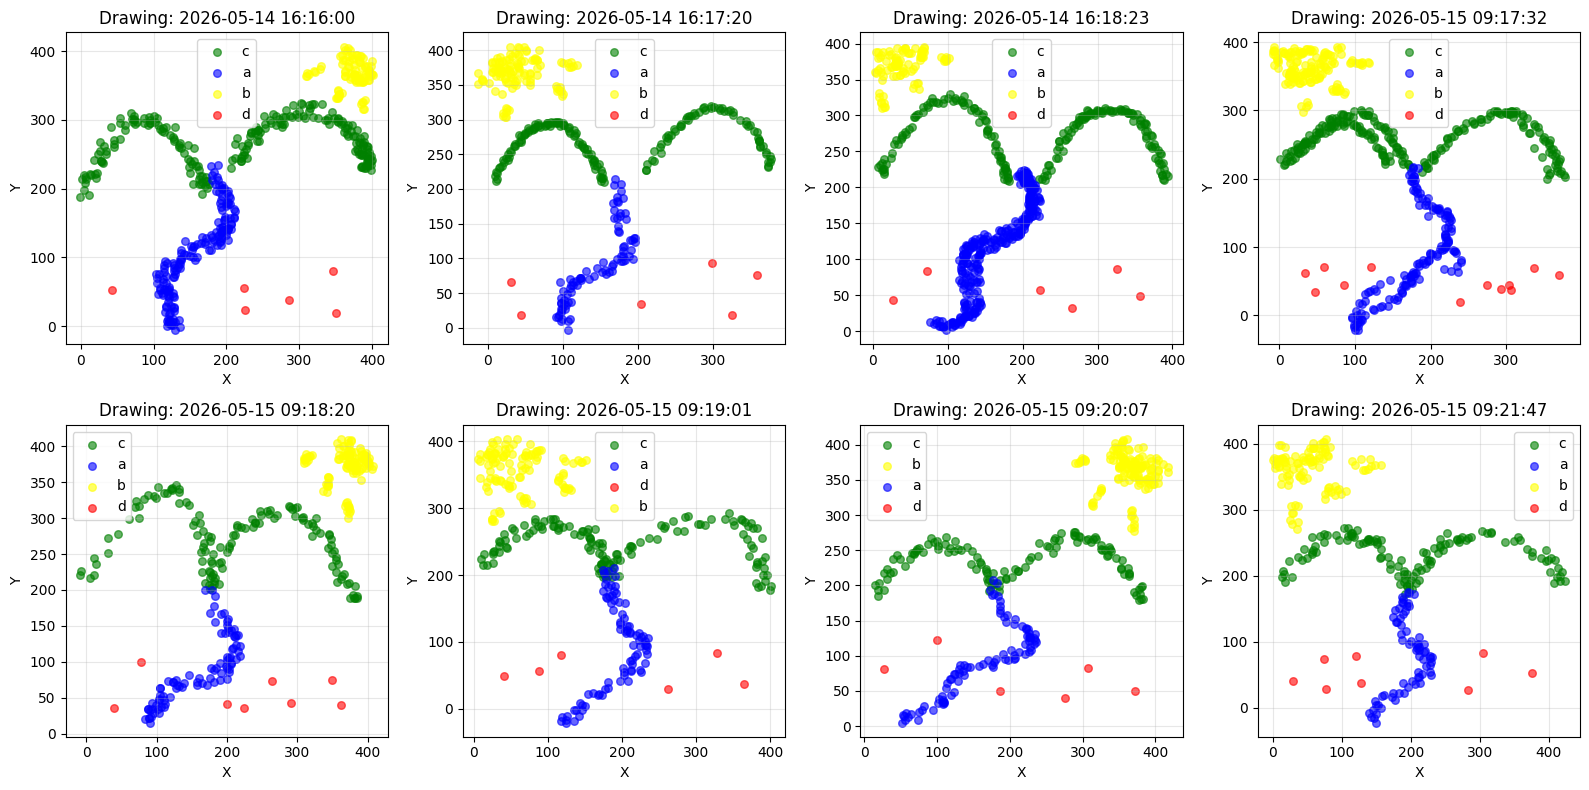

In [26]:
import matplotlib.pyplot as plt

# Define color mapping for labels
color_map = {'a': 'blue', 'b': 'yellow', 'c': 'green', 'd': 'red'}

# Get unique datetimes (each drawing)
datetimes = df['datetime'].unique()

print("NUMBER OF DRAWINGS:", len(datetimes))

# Create subplots - one for each drawing
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Plot each drawing on its own axis
for idx, datetime_val in enumerate(datetimes):
    drawing_df = df[df['datetime'] == datetime_val]
    ax = axes[idx]
    
    for label in drawing_df['label'].unique():
        label_df = drawing_df[drawing_df['label'] == label]
        ax.scatter(label_df['x'], label_df['y'], 
                   color=color_map[label], 
                   label=label, 
                   alpha=0.6, s=30)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Drawing: {datetime_val}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(datetimes), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Manual Upload To IRIS

In [23]:
# Configuration
server = os.getenv("IRIS_SERVER")
port = os.getenv("IRIS_PORT") # Standard InterSystems superserver port
namespace = os.getenv("IRIS_NAMESPACE")
username = os.getenv("IRIS_USERNAME")
password = os.getenv("IRIS_PASSWORD")

engine = create_engine(f"iris://{username}:{password}@{server}:{port}/{namespace}")

df.to_sql("PointSamples", engine, schema="MLpipeline", if_exists='append', index=False, method='multi')


-1